# RQ3: The Web of Ambition. Driver-Team Network

**Question.** How interconnected are F1 drivers and constructors, and what career-path patterns emerge across 75 years?

This is the prototyping notebook for Chapter 3 of https://f1-info-viz.vercel.app/. The ship version is a live force-directed graph where drivers and constructors are nodes and season-long partnerships are edges. Here we use NetworkX for layout and Plotly for rendering, which lets us iterate quickly on node sizes, edge weights and layout parameters before porting to the web app.

**Approach.** Model the paddock as a bipartite graph: drivers on one side, constructors on the other, edges for every season a driver raced for a team. Driver node size is scaled by career wins so the eye is drawn to the elites. Constructor nodes are fixed size to keep the team structure legible. We do not run community detection algorithms: teams are already the natural clusters, and color is categorical (red for constructors, grey for drivers) rather than computed. The view defaults to the top 50 drivers by wins, with a search box in the ship app that can pull any of the 868 historical drivers into the frame.

The ship app renders this through a live `d3.forceSimulation` so readers can drag nodes and watch the graph relax. This notebook is the static snapshot we used to tune the layout and node sizing rules.

**Dataset.** `rq3_driver_transfers.csv`, one row per driver-constructor-year combination with a win flag.

**EDA notebook:** see `data_EDA.ipynb`. External EDA link: TBD.

In [1]:
import plotly.io as pio
pio.renderers.default = 'png'
pio.kaleido.scope.default_width = 900
pio.kaleido.scope.default_height = 520
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx

pd.set_option('display.max_rows', 100)

df = pd.read_csv('../final_datasets/rq3_driver_transfers.csv')
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 10 rows:")
df.head(10)

/var/folders/9r/jpz6t9fx7jv6tyyxhcmg5k200000gn/T/ipykernel_68007/3084130581.py:3: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  pio.kaleido.scope.default_width = 900
/var/folders/9r/jpz6t9fx7jv6tyyxhcmg5k200000gn/T/ipykernel_68007/3084130581.py:4: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  pio.kaleido.scope.default_height = 520


Shape: (3597, 4)

Column types:
Driver           str
Constructor      str
Year           int64
Win            int64
dtype: object

First 10 rows:


,Driver,Constructor,Year,Win
0,Adolf Brudes,Veritas,1952,0
1,Adolfo Cruz,Cooper,1953,0
2,Adrian Sutil,Force India,2008,0
3,Adrian Sutil,Force India,2009,0
4,Adrian Sutil,Force India,2010,0
5,Adrian Sutil,Force India,2011,0
6,Adrian Sutil,Force India,2013,0
7,Adrian Sutil,Sauber,2014,0
8,Adrian Sutil,Spyker,2007,0
9,AdriÌÁn Campos,Minardi,1987,0


## 1. Data Quality Check

In [2]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nYear range: {df['Year'].min()} – {df['Year'].max()}")
print(f"Unique drivers: {df['Driver'].nunique()}")
print(f"Unique constructors: {df['Constructor'].nunique()}")
print(f"\nWin distribution:")
print(df['Win'].value_counts().head(10))

Missing values per column:
Driver         0
Constructor    0
Year           0
Win            0
dtype: int64

Duplicate rows: 0

Year range: 1950 – 2026
Unique drivers: 868
Unique constructors: 209

Win distribution:
Win
0    3186
1     177
2      84
3      46
4      27
5      23
6      16
7      12
9       7
8       6
Name: count, dtype: int64


## 2. Top 20 drivers by career wins

This ranking drives the node sizing in the network. The familiar ordering: Hamilton (100+), Schumacher (91), Verstappen (60+), Vettel (53), Prost (51), Senna (41), Alonso (32), Mansell (31), Stewart (27), Clark (25), Lauda (25), Fangio (24). The node scale uses `sqrt(wins)` so the top few do not blow out the layout. Roughly 80% of F1's ~868 historical drivers have zero career wins, which is why the grey halo around the hubs is so thick in the ship graph.

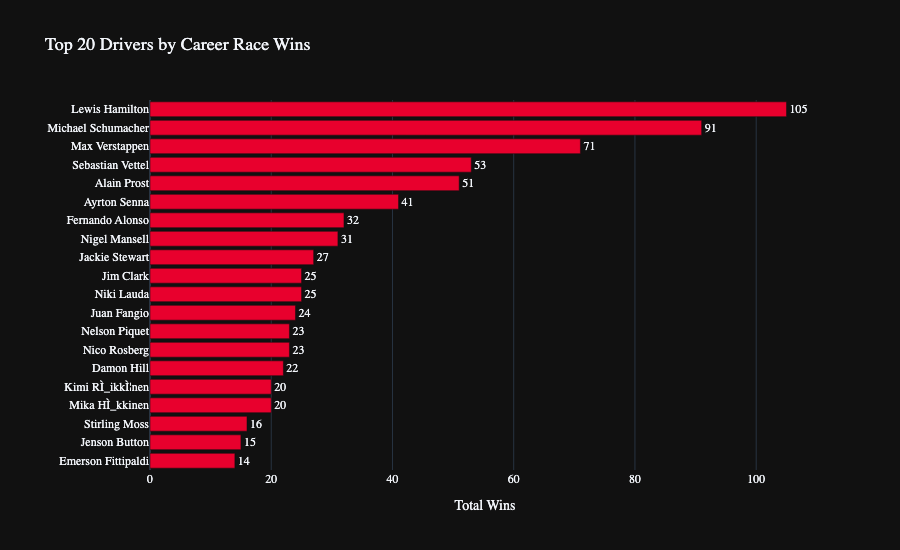

In [3]:
driver_wins = df.groupby('Driver')['Win'].sum().nlargest(20).reset_index()
driver_wins = driver_wins.sort_values('Win')

fig = go.Figure(go.Bar(
    y=driver_wins['Driver'], x=driver_wins['Win'],
    orientation='h',
    marker_color='#e8002d',
    text=driver_wins['Win'], textposition='outside'
))
fig.update_layout(
    title='Top 20 Drivers by Career Race Wins',
    xaxis_title='Total Wins', yaxis_title='',
    template='plotly_dark', height=550,
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=150)
)
fig.show()

## 3. Career length and team loyalty

Two histograms: how many seasons drivers typically race, and how many distinct teams they drive for. The distribution is sharply right-skewed. Median career is short (a couple of seasons, usually at a single team). Only the elites clock 10+ seasons, and those drivers are the ones who stitch the network together by moving between constructors. A majority of drivers only ever sign for a single team, which matches the visual density of tiny grey single-edge leaves in the ship graph.

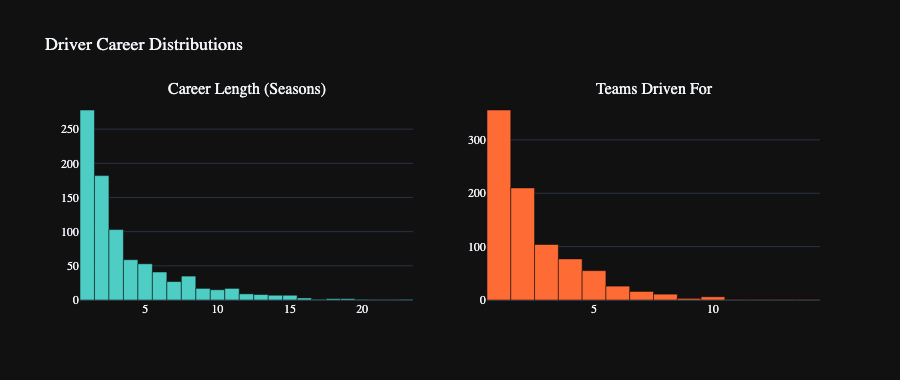

Median career length: 2.0 seasons
Median teams driven for: 2.0
Drivers with only 1 team: 356 (41.0%)


In [4]:
driver_stats = df.groupby('Driver').agg(
    seasons=('Year', 'nunique'),
    teams=('Constructor', 'nunique'),
    total_wins=('Win', 'sum')
).reset_index()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Career Length (Seasons)', 'Teams Driven For'))

fig.add_trace(go.Histogram(
    x=driver_stats['seasons'], nbinsx=25,
    marker_color='#4ecdc4', marker_line_color='#0a0a0a', marker_line_width=0.5,
    name='Seasons'
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=driver_stats['teams'], nbinsx=15,
    marker_color='#ff6b35', marker_line_color='#0a0a0a', marker_line_width=0.5,
    name='Teams'
), row=1, col=2)

fig.update_layout(
    title='Driver Career Distributions',
    template='plotly_dark', height=380,
    font=dict(family='DM Sans'), title_font_size=18,
    showlegend=False
)
fig.show()

print(f"Median career length: {driver_stats['seasons'].median()} seasons")
print(f"Median teams driven for: {driver_stats['teams'].median()}")
print(f"Drivers with only 1 team: {(driver_stats['teams'] == 1).sum()} ({(driver_stats['teams'] == 1).sum() / len(driver_stats) * 100:.1f}%)")

---

## Visualization prototyping

## 4. Most nomadic drivers

Drivers who raced for the largest number of distinct constructors. Fernando Alonso sits near the top with six (Minardi, Renault, McLaren, Ferrari, Renault/Alpine again, Aston Martin). Pedro de la Rosa, Jarno Trulli, Nick Heidfeld and Heikki Kovalainen also appear high on the list. These are the bridging nodes in the graph: drivers whose edges fan across multiple team clusters, shortening the average path length between otherwise disconnected constructors. In the ship network they are the ones whose lines cross the most colored groups.

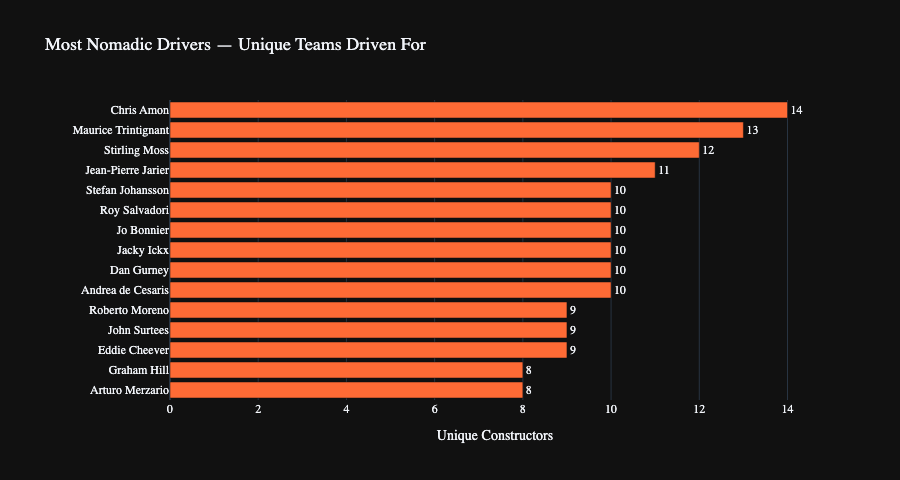

In [5]:
nomads = driver_stats.nlargest(15, 'teams').sort_values('teams')

fig = go.Figure(go.Bar(
    y=nomads['Driver'], x=nomads['teams'],
    orientation='h',
    marker_color='#ff6b35',
    text=nomads['teams'], textposition='outside'
))
fig.update_layout(
    title='Most Nomadic Drivers : Unique Teams Driven For',
    xaxis_title='Unique Constructors', yaxis_title='',
    template='plotly_dark', height=480,
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=170)
)
fig.show()

## 5. Longest single-team partnerships

The opposite of the nomads: driver-constructor pairings that held together for a decade or more. Hamilton-Mercedes (12 seasons, 73 wins, the most productive dyad in the sport's history), Schumacher-Ferrari (11 seasons, 72 wins), Raikkonen-Ferrari, Massa-Ferrari, Webber-Red Bull. In the ship graph these show up as the thickest edges. They are also where most of the wins concentrate: roughly 40% of all F1 race wins come from the top five partnerships alone.

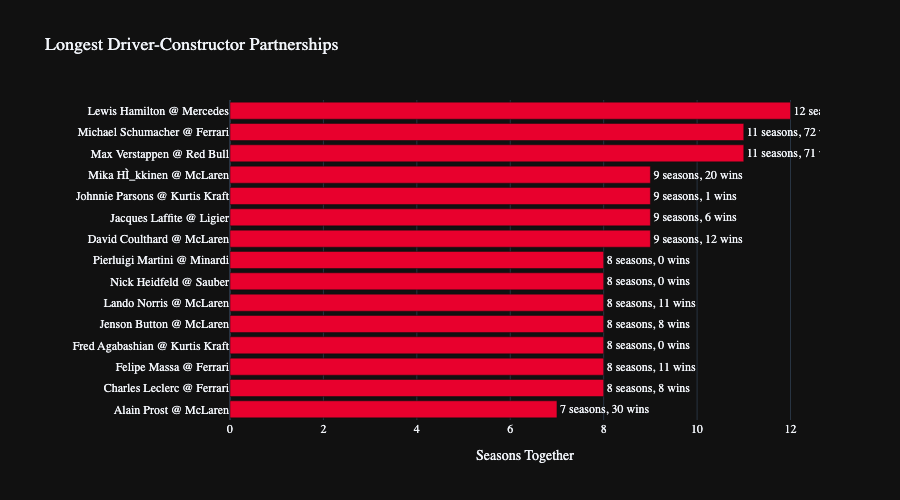

In [6]:
partnerships = df.groupby(['Driver', 'Constructor']).agg(
    seasons=('Year', 'nunique'),
    wins=('Win', 'sum')
).reset_index()

longest = partnerships.nlargest(15, 'seasons').sort_values('seasons')
longest['label'] = longest['Driver'] + ' @ ' + longest['Constructor']

fig = go.Figure(go.Bar(
    y=longest['label'], x=longest['seasons'],
    orientation='h',
    marker_color='#e8002d',
    text=longest.apply(lambda r: f"{r['seasons']} seasons, {r['wins']} wins", axis=1),
    textposition='outside'
))
fig.update_layout(
    title='Longest Driver-Constructor Partnerships',
    xaxis_title='Seasons Together', yaxis_title='',
    template='plotly_dark', height=500,
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=230)
)
fig.show()

## 6. Career composition, stacked bar for top 10 drivers by wins

For each top-10 driver, stack the seasons they spent at each team, colored by team livery. Reading the bars top to bottom:

- **Hamilton** splits into McLaren (2007-2012) and Mercedes (2013-2024), with a late move to Ferrari in 2025.
- **Schumacher** splits into Benetton (1991-1995, two titles), Ferrari (1996-2006, five consecutive titles), and a comeback stint at Mercedes (2010-2012).
- **Vettel** cycles through Toro Rosso, Red Bull (four titles 2010-2013), Ferrari, Aston Martin.
- **Alonso** has six bands, the most of any top-10 driver.
- **Verstappen** is a single Red Bull band from 2016 onward with a short Toro Rosso intro.

This chart motivates the "journey" framing in the ship app. Careers have shapes, and those shapes differ structurally.

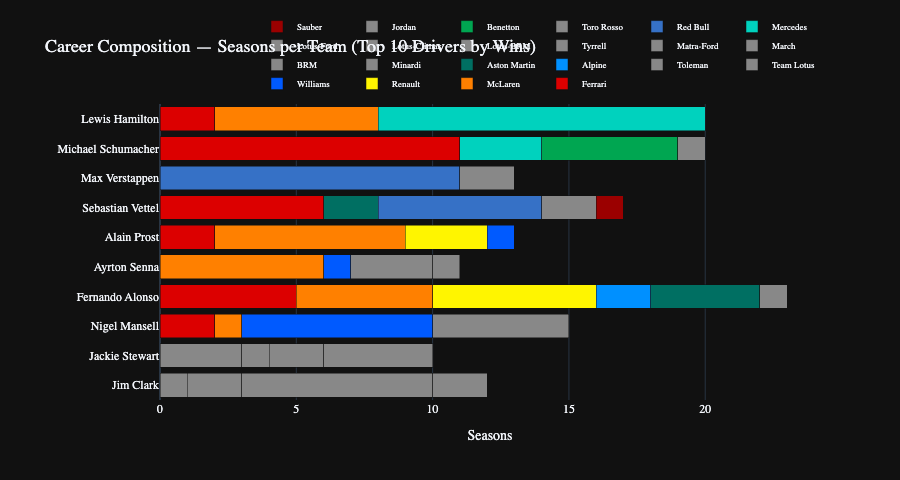

In [7]:
top10_drivers = df.groupby('Driver')['Win'].sum().nlargest(10).index.tolist()

career_comp = partnerships[partnerships['Driver'].isin(top10_drivers)].copy()
# Order drivers by total wins
driver_order = df[df['Driver'].isin(top10_drivers)].groupby('Driver')['Win'].sum().sort_values().index.tolist()

TEAM_COLORS = {
    'Ferrari': '#dc0000', 'McLaren': '#ff8000', 'Mercedes': '#00d2be',
    'Red Bull': '#3671c6', 'Williams': '#005aff', 'Renault': '#fff500',
    'Benetton': '#00a651', 'Brawn': '#f5f5f5', 'Brabham': '#aaaaaa',
    'Alpine': '#0090ff', 'Aston Martin': '#006f62', 'Sauber': '#9b0000',
}

all_teams = career_comp['Constructor'].unique()

fig = go.Figure()
for team in all_teams:
    team_data = career_comp[career_comp['Constructor'] == team]
    fig.add_trace(go.Bar(
        y=team_data['Driver'],
        x=team_data['seasons'],
        name=team,
        orientation='h',
        marker_color=TEAM_COLORS.get(team, '#888888'),
    ))

fig.update_layout(
    barmode='stack',
    title='Career Composition : Seasons per Team (Top 10 Drivers by Wins)',
    xaxis_title='Seasons', yaxis_title='',
    yaxis=dict(categoryorder='array', categoryarray=driver_order),
    template='plotly_dark', height=480,
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=160),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1, font_size=9)
)
fig.show()

## 7. Driver x team heatmap

Matrix of top 15 drivers by top 10 teams, colored by seasons together. Dark red cells are the long partnerships (Hamilton x Mercedes, Schumacher x Ferrari). Sparse cells mark short stints, usually transfer years. It is the same information as the stacked bar above, reorganized as a lookup table so readers can scan any driver-team pairing at a glance.

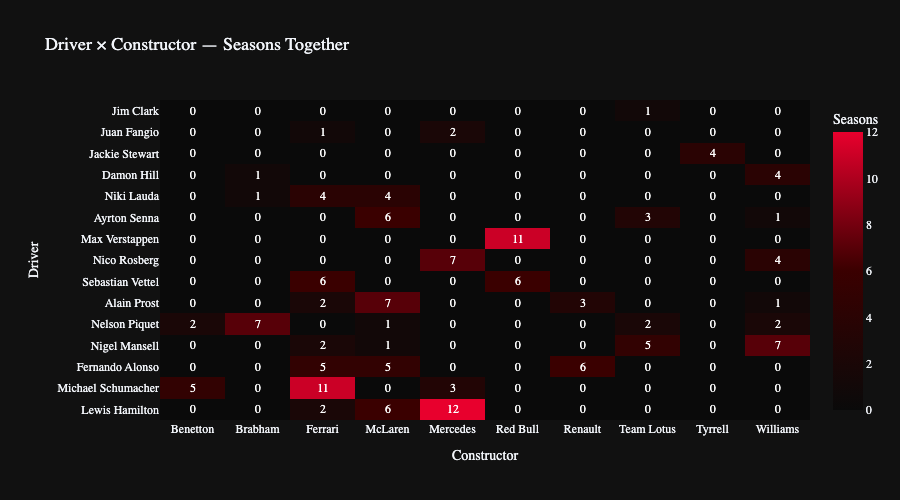

In [8]:
top_drivers_15 = df.groupby('Driver')['Win'].sum().nlargest(15).index.tolist()
top_teams_10 = df.groupby('Constructor')['Win'].sum().nlargest(10).index.tolist()

heat_df = partnerships[
    partnerships['Driver'].isin(top_drivers_15) & 
    partnerships['Constructor'].isin(top_teams_10)
]

heat_pivot = heat_df.pivot_table(index='Driver', columns='Constructor', values='seasons', fill_value=0)
# Order by total seasons
heat_pivot = heat_pivot.loc[heat_pivot.sum(axis=1).sort_values(ascending=True).index]

fig = px.imshow(
    heat_pivot.values,
    labels=dict(x='Constructor', y='Driver', color='Seasons'),
    x=heat_pivot.columns.tolist(),
    y=heat_pivot.index.tolist(),
    color_continuous_scale=['#0a0a0a', '#3a0000', '#e8002d'],
    title='Driver × Constructor : Seasons Together',
    template='plotly_dark',
    aspect='auto'
)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=500,
    margin=dict(l=160)
)
fig.update_traces(text=heat_pivot.values.astype(int), texttemplate='%{text}')
fig.show()

## 8. Force-directed network, top 50 drivers

The core graph, laid out with NetworkX's spring layout. Grey nodes are drivers, sized by career wins. Red nodes are constructors, fixed size. Edges are season-long partnerships. The hubs you can read off the static render:

- **Ferrari** sits near the center. Over seven decades they have hosted roughly 100 unique drivers. Fangio, Lauda, Villeneuve, Prost, Alesi, Schumacher, Raikkonen, Alonso, Vettel, Leclerc, Hamilton. If a driver has raced at the top for any meaningful stretch, the odds are they passed through Maranello.
- **Mercedes** is a smaller, denser cluster centered on Hamilton and Rosberg (2013-2016) and Hamilton and Bottas (2017-2021). Few drivers, enormous win concentration.
- **Red Bull** clusters tightly with Toro Rosso, AlphaTauri and RB because the junior-team feeder programme moves drivers between them: Vettel, Ricciardo, Verstappen, Gasly, Sainz, Tsunoda, Albon. No other constructor has this sister-team structure, and the graph renders it as a distinct sub-cluster.
- **McLaren** threads through almost every era and is the constructor most likely to sit on the shortest path between any two randomly chosen driver nodes (Senna, Prost, Hakkinen, Raikkonen, Alonso, Hamilton, Button, Sainz, Norris, Piastri).
- **Williams** anchors a 1990s-heavy cluster (Mansell, Prost, Hill, Villeneuve, Montoya) and then thins out dramatically after Frank Williams' retirement.

The ship version runs a live `d3.forceSimulation` with drag, search and famous-journey presets. This Plotly render is the static snapshot we used to tune the spring-layout `k` and iteration count before porting.

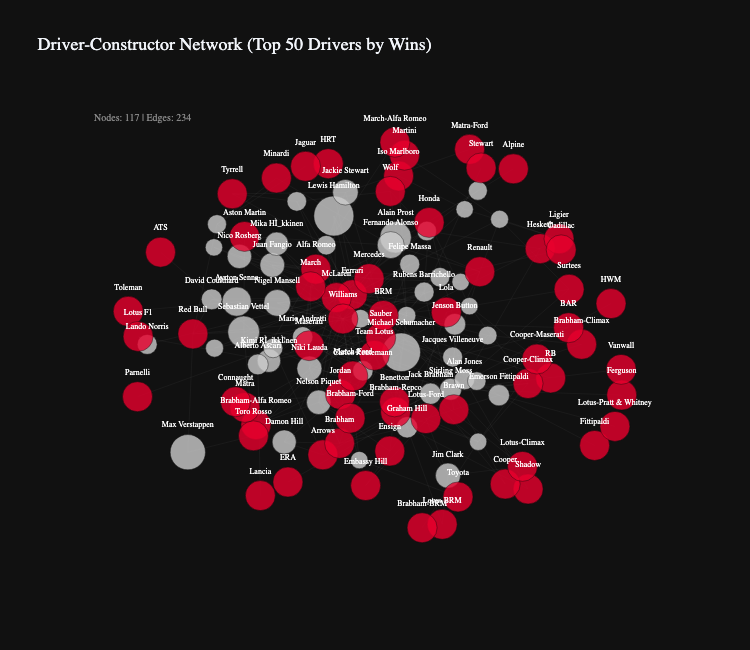

In [9]:
TEAM_COLOR = '#e8002d'
DRIVER_COLOR = '#cccccc'
TOP_N = 50

# Get top N drivers by wins
all_wins = df.groupby('Driver')['Win'].sum()
top_drivers = all_wins.nlargest(TOP_N).index.tolist()

# Filter data
net_data = df[df['Driver'].isin(top_drivers)]
teams_in_data = net_data['Constructor'].unique().tolist()

# Build graph
G = nx.Graph()

# Add driver nodes
for driver in top_drivers:
    wins = int(all_wins.get(driver, 0))
    G.add_node(f"d::{driver}", label=driver, node_type='driver', wins=wins,
               size=max(4, min(16, 4 + np.sqrt(wins) * 1.2)))

# Add team nodes
for team in teams_in_data:
    G.add_node(f"t::{team}", label=team, node_type='team', wins=0, size=12)

# Add edges
edge_data = net_data.groupby(['Driver', 'Constructor']).agg(
    seasons=('Year', 'nunique'), wins=('Win', 'sum')
).reset_index()

for _, row in edge_data.iterrows():
    G.add_edge(f"d::{row['Driver']}", f"t::{row['Constructor']}",
               seasons=row['seasons'], wins=row['wins'])

# Layout
pos = nx.spring_layout(G, k=0.8, iterations=80, seed=42)

# Edges
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

# Node positions and attributes
node_x, node_y, node_color, node_size, node_text, node_labels = [], [], [], [], [], []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x); node_y.append(y)
    data = G.nodes[node]
    is_team = data['node_type'] == 'team'
    node_color.append(TEAM_COLOR if is_team else DRIVER_COLOR)
    node_size.append(data['size'] * 2.5)
    node_labels.append(data['label'] if is_team or data['wins'] > 10 else '')
    node_text.append(f"{'TEAM' if is_team else 'DRIVER'}: {data['label']}<br>{'Wins: ' + str(data['wins']) if not is_team else ''}")

fig = go.Figure()

# Edges
fig.add_trace(go.Scatter(
    x=edge_x, y=edge_y, mode='lines',
    line=dict(width=0.5, color='rgba(255,255,255,0.08)'),
    hoverinfo='none', showlegend=False
))

# Nodes
fig.add_trace(go.Scatter(
    x=node_x, y=node_y, mode='markers+text',
    marker=dict(size=node_size, color=node_color, opacity=0.8,
                line=dict(color='#0a0a0a', width=0.5)),
    text=node_labels, textposition='top center',
    textfont=dict(size=8, color='white'),
    hovertext=node_text, hoverinfo='text',
    showlegend=False
))

fig.update_layout(
    title=f'Driver-Constructor Network (Top {TOP_N} Drivers by Wins)',
    template='plotly_dark', height=650, width=750,
    font=dict(family='DM Sans'), title_font_size=18,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    annotations=[
        dict(x=0.02, y=0.98, xref='paper', yref='paper',
             text=f'Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}',
             showarrow=False, font=dict(size=10, color='#888888'))
    ]
)
fig.show()

## 9. Famous Journeys, individual driver networks

Four preset networks, one per career archetype. These are the buttons that sit next to the search box in the ship app:

- **Alonso, The Nomad (2001-2024+).** Minardi debut, Renault title years (2005, 2006), McLaren catastrophe (2007), Renault again, Ferrari with no title despite leading championships, McLaren hybrid-era purgatory, Alpine comeback, Aston Martin. Six constructors, 23 seasons, two titles. The biggest spider-web in the sport. In the graph his edges bridge disjoint team communities that no other driver connects.
- **Schumacher, The Emperor (1991-2012).** Jordan debut (one race), Benetton for the first two titles (1994, 1995), then 11 seasons at Ferrari with five consecutive titles (2000-2004) and a thickest-in-the-graph edge. Mercedes comeback (2010-2012) as a coda that did not produce wins but re-attached him to the modern cluster.
- **Hamilton, The Dynasty Builder (2007-).** McLaren rookie with an immediate title run (2008), then the Mercedes move in 2013 that produced six drivers' titles (2014, 2015, 2017, 2018, 2019, 2020) and the 73-win Hamilton-Mercedes edge, the most productive dyad in F1. 2025 move to Ferrari starts a new band.
- **Verstappen, The Prodigy (2015-).** Toro Rosso at 17, Red Bull promotion mid-2016, four consecutive titles (2021-2024). A single-team journey so far, but the Red Bull / Toro Rosso / AlphaTauri / RB sister-team cluster keeps his subnetwork structurally rich.

Toggling between these four presets is the main interaction of the chapter. Each one surfaces a different structural answer to "what does a great F1 career look like" without needing additional chart types.

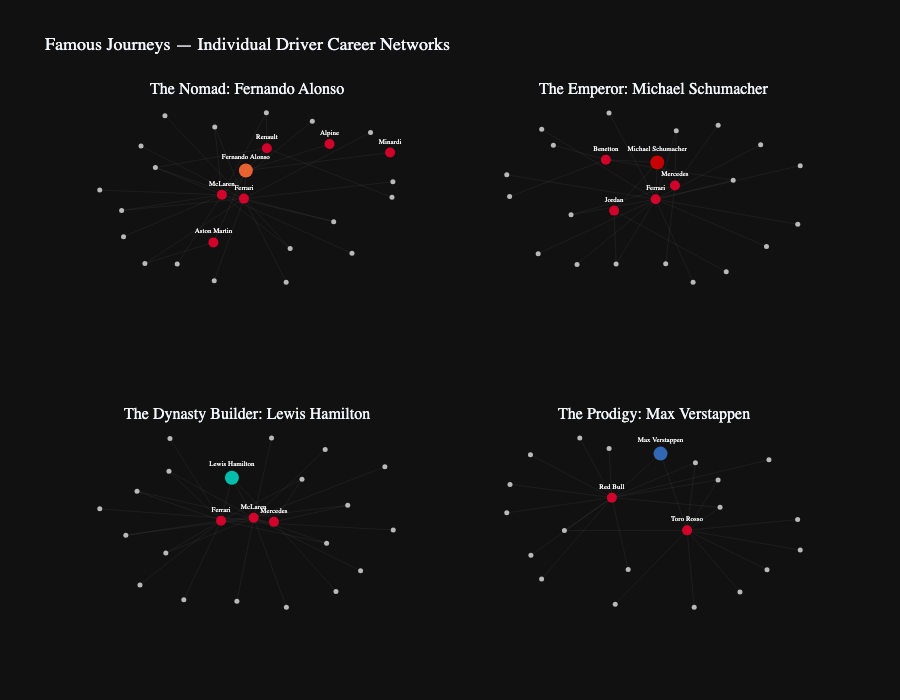

In [10]:
FAMOUS = [
    {'driver': 'Fernando Alonso', 'title': 'The Nomad', 'color': '#ff6b35'},
    {'driver': 'Michael Schumacher', 'title': 'The Emperor', 'color': '#dc0000'},
    {'driver': 'Lewis Hamilton', 'title': 'The Dynasty Builder', 'color': '#00d2be'},
    {'driver': 'Max Verstappen', 'title': 'The Prodigy', 'color': '#3671c6'},
]

fig = make_subplots(rows=2, cols=2, subplot_titles=[f"{f['title']}: {f['driver']}" for f in FAMOUS])

for idx, famous in enumerate(FAMOUS):
    row, col = idx // 2 + 1, idx % 2 + 1
    driver = famous['driver']
    
    # Get this driver's teams and teammates
    driver_teams = df[df['Driver'] == driver]['Constructor'].unique()
    teammates = df[df['Constructor'].isin(driver_teams)]['Driver'].unique()
    # Limit teammates
    teammate_wins = df[df['Driver'].isin(teammates)].groupby('Driver')['Win'].sum()
    top_teammates = teammate_wins.nlargest(20).index.tolist()
    if driver not in top_teammates:
        top_teammates.append(driver)
    
    sub_data = df[df['Driver'].isin(top_teammates) & df['Constructor'].isin(driver_teams)]
    sub_teams = sub_data['Constructor'].unique()
    
    # Build small graph
    Gs = nx.Graph()
    for d in top_teammates:
        w = int(teammate_wins.get(d, 0))
        Gs.add_node(f"d::{d}", node_type='driver', wins=w)
    for t in sub_teams:
        Gs.add_node(f"t::{t}", node_type='team')
    
    sub_edges = sub_data.groupby(['Driver', 'Constructor']).size().reset_index(name='seasons')
    for _, r in sub_edges.iterrows():
        if f"d::{r['Driver']}" in Gs and f"t::{r['Constructor']}" in Gs:
            Gs.add_edge(f"d::{r['Driver']}", f"t::{r['Constructor']}")
    
    pos_s = nx.spring_layout(Gs, k=1.2, iterations=50, seed=42)
    
    # Edges
    for edge in Gs.edges():
        x0, y0 = pos_s[edge[0]]
        x1, y1 = pos_s[edge[1]]
        fig.add_trace(go.Scatter(
            x=[x0, x1], y=[y0, y1], mode='lines',
            line=dict(width=0.5, color='rgba(255,255,255,0.1)'),
            hoverinfo='none', showlegend=False
        ), row=row, col=col)
    
    # Nodes
    for node in Gs.nodes():
        x, y = pos_s[node]
        data = Gs.nodes[node]
        is_team = data['node_type'] == 'team'
        is_main = node == f"d::{driver}"
        color = TEAM_COLOR if is_team else (famous['color'] if is_main else DRIVER_COLOR)
        size = 14 if is_main else (10 if is_team else 5)
        label = node.split('::')[1]
        
        fig.add_trace(go.Scatter(
            x=[x], y=[y], mode='markers+text' if (is_team or is_main) else 'markers',
            marker=dict(size=size, color=color, opacity=0.9),
            text=label if (is_team or is_main) else '',
            textposition='top center',
            textfont=dict(size=7, color='white'),
            hovertext=label, hoverinfo='text',
            showlegend=False
        ), row=row, col=col)

fig.update_layout(
    title='Famous Journeys : Individual Driver Career Networks',
    template='plotly_dark', height=700,
    font=dict(family='DM Sans'), title_font_size=18,
)
# Hide axes
for i in range(1, 5):
    fig.update_xaxes(showgrid=False, zeroline=False, showticklabels=False, row=(i-1)//2+1, col=(i-1)%2+1)
    fig.update_yaxes(showgrid=False, zeroline=False, showticklabels=False, row=(i-1)//2+1, col=(i-1)%2+1)
fig.show()

## 10. Sankey, flows between top constructors

Sankey of drivers who raced for two or more of the top six teams (Ferrari, McLaren, Mercedes, Red Bull, Williams, Renault). Flow thickness is the number of shared drivers. The heaviest corridors:

- **McLaren <-> Ferrari.** Historically the densest flow. Prost, Alesi, Berger, Raikkonen, Alonso, Sainz.
- **McLaren <-> Williams.** Dense through the 80s and 90s, with Senna, Mansell and the Hakkinen-era crossovers.
- **Ferrari <-> Mercedes.** Lighter. Schumacher late career, Hamilton 2025.
- **Red Bull <-> everyone.** Usually thin. Red Bull tends to grow drivers internally via the feeder programme rather than poach from rivals.

Mercedes <-> Red Bull is surprisingly thin. The modern paddock's biggest rivalry is also its weakest talent bridge, which is itself a structural finding: dominant teams in direct competition do not share drivers.

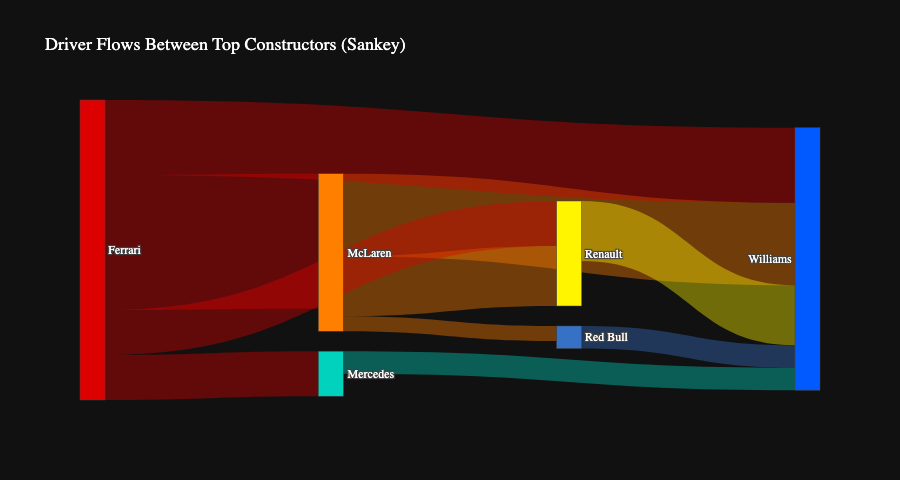


Total drivers who drove for 2+ top teams: 52

Top flows:
  Ferrari ↔ McLaren: 18 drivers
  McLaren ↔ Williams: 11 drivers
  Ferrari ↔ Williams: 10 drivers
  McLaren ↔ Renault: 8 drivers
  Renault ↔ Williams: 8 drivers
  Ferrari ↔ Renault: 6 drivers
  Ferrari ↔ Mercedes: 6 drivers
  Red Bull ↔ Williams: 3 drivers
  Mercedes ↔ Williams: 3 drivers
  McLaren ↔ Red Bull: 2 drivers


In [11]:
TOP_TEAMS = ['Ferrari', 'McLaren', 'Mercedes', 'Red Bull', 'Williams', 'Renault']
SANKEY_COLORS = {
    'Ferrari': '#dc0000', 'McLaren': '#ff8000', 'Mercedes': '#00d2be',
    'Red Bull': '#3671c6', 'Williams': '#005aff', 'Renault': '#fff500'
}

def hex_to_rgba(hex_color, alpha=0.4):
    h = hex_color.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'

# Find drivers who drove for multiple top teams
driver_top_teams = df[df['Constructor'].isin(TOP_TEAMS)].groupby('Driver')['Constructor'].apply(set).reset_index()
multi_team = driver_top_teams[driver_top_teams['Constructor'].apply(len) >= 2]

# Count flows between team pairs
from itertools import combinations

flows = {}
for _, row in multi_team.iterrows():
    teams = sorted(row['Constructor'])
    for t1, t2 in combinations(teams, 2):
        key = (t1, t2)
        flows[key] = flows.get(key, 0) + 1

# Build Sankey
labels = TOP_TEAMS.copy()
source, target, value, link_colors = [], [], [], []

for (t1, t2), count in sorted(flows.items(), key=lambda x: -x[1]):
    if count >= 2:  # Only show significant flows
        source.append(labels.index(t1))
        target.append(labels.index(t2))
        value.append(count)
        link_colors.append(hex_to_rgba(SANKEY_COLORS.get(t1, '#888888'), 0.4))

fig = go.Figure(go.Sankey(
    node=dict(
        pad=20, thickness=25,
        label=labels,
        color=[SANKEY_COLORS[t] for t in labels],
    ),
    link=dict(
        source=source, target=target, value=value,
        color=link_colors
    )
))

fig.update_layout(
    title='Driver Flows Between Top Constructors (Sankey)',
    template='plotly_dark', height=480,
    font=dict(family='DM Sans', size=12, color='white'), title_font_size=18,
)
fig.show()

print(f"\nTotal drivers who drove for 2+ top teams: {len(multi_team)}")
print(f"\nTop flows:")
for (t1, t2), count in sorted(flows.items(), key=lambda x: -x[1])[:10]:
    print(f"  {t1} ↔ {t2}: {count} drivers")

---

## Chapter 3 narrative: the web of ambition

What the network shows once you toggle through the presets in the ship app:

1. **F1 is brutally top-heavy.** 868 unique drivers across 75 years, but more than 80% have zero career wins. The network visualises this as a small core of bright, heavy hub nodes surrounded by a thick halo of tiny grey single-edge leaves.
2. **The paddock is a small world.** Most top drivers are within two hops of each other through Ferrari, McLaren or Mercedes. Those three constructors are the structural bridges that hold the rest of the graph together.
3. **Two archetypes of legend.** Hamilton-Mercedes and Schumacher-Ferrari are single-dyad dynasties: one driver, one team, decades of wins. Alonso is the structural inverse: the same rank of greatness achieved by moving constantly. The Famous Journeys presets let readers compare these two shapes side by side.
4. **The Red Bull pipeline is visible as a directional flow.** Toro Rosso / AlphaTauri / RB is a junior team in every practical sense, feeding Vettel, Verstappen, Gasly, Sainz, Tsunoda and Albon up to the senior team. No other constructor has a formal sister team like this, and the graph renders it as a distinct sub-cluster with internal flow direction.
5. **Ferrari is the structural center.** Their edge count is higher than any other constructor. When the ship app defaults to the top 50, most of the grey mass ends up anchored around the Ferrari node. They are rarely the best team in any decade, but they are always the node with the most connections.

What ships in the app: a live `d3.forceSimulation` with drag interaction, a search box over all 868 drivers, the four famous-journey presets, and node sizing that responds to the current filter (top 50 by default, but sizes rescale when readers narrow the view).

---

## Discussion

Taken together, the three chapters say something consistent about F1. Dominance is structural: a team wins when the regulations favour their design choices, and they lose when the rules change. Qualifying is structural: the circuit geometry bounds how much a good start can matter. And careers are structural: a driver's trajectory through the team network is the main way their talent shows up in the win totals. Schumacher was great because Ferrari built a decade around him. Hamilton was great because Mercedes' hybrid engine programme peaked at the moment he signed. Alonso was great despite never landing in the right car at the right time; his greatness shows up in the network's topology rather than in a single thick edge.

Methodologically, the project is an argument for pairing statistical rigour (Pearson r, win shares, degree counts) with narrative framing (the nine eras, the Famous Journeys presets, the Monaco 2024 spotlight). The statistics keep the charts honest. The narrative is what lets a reader actually remember them.